# Fire & Smoke Detection with Human Motion Tracking


---
# Imports and Setup



In [1]:
# Core imports
import os, gc, time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
from tqdm.notebook import tqdm

# Make matplotlib display figures inline
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['image.cmap'] = 'gray'

print(f"OpenCV version : {cv2.__version__}")
print(f"NumPy  version : {np.__version__}")


OpenCV version : 4.13.0
NumPy  version : 2.4.4


##  Project paths and configuration


In [ ]:
# ---- Paths ----------------------------------------------------------------
DATASET_DIR = Path('data')          # contains part1/, part2/, part3/
OUTPUT_DIR  = Path('outputs')       # processed videos + saved figures land here
OUTPUT_DIR.mkdir(exist_ok=True)

# ---- Detection / display parameters ---------------------------------------
PARAMS = {
    # ----- Background subtraction (MOG2) -----
    'mog2_history':       200,
    'mog2_var_threshold': 20,
    'mog2_detect_shadows': True,

    # ----- Frame differencing (catches slow motion MOG2 absorbs) -----
    'diff_threshold': 18,
    'diff_long_dt':   8,        # how many frames back the *long* diff looks

    # ----- Pre-processing -----
    'blur_ksize':   (5, 5),
    'morph_kernel': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),

    # ----- Contour-area thresholds (in pixels at 640px-wide working size) -----
    'min_area_human': 1200,
    'min_area_fire':   200,
    'min_area_smoke':  800,

    # ----- Drawing colors (BGR for OpenCV) -----
    'color_human': (0, 255,   0),   # green
    'color_fire':  (0,   0, 255),   # red
    'color_smoke': (255, 128, 0),   # blue-ish

    'process_width':  640,
    'max_frames':     900,    # at 25 FPS this is ~36 s of video per clip
}

print('Dataset directory :', DATASET_DIR.resolve())
print('Output  directory :', OUTPUT_DIR.resolve())


Dataset directory : D:\cv\data
Output  directory : D:\cv\outputs


---
# Video Loading & Exploration



In [3]:
def list_videos(dataset_dir: Path):
    """Return [(label, path), ...] for every .mp4 inside dataset_dir/part*/."""
    videos = []
    for part_dir in sorted(dataset_dir.glob('part*')):
        for video in sorted(part_dir.glob('*.mp4')):
            label = f"{part_dir.name}/{video.stem}"
            videos.append((label, video))
    return videos


VIDEOS = list_videos(DATASET_DIR)
for label, path in VIDEOS:
    print(f"  - {label:<30s} -> {path}")
assert len(VIDEOS) == 3, f"Expected 3 videos, found {len(VIDEOS)}"


  - part1/bucket11                 -> data\part1\bucket11.mp4
  - part2/roomfire41               -> data\part2\roomfire41.mp4
  - part3/printer31                -> data\part3\printer31.mp4


In [4]:
def video_info(path: Path) -> dict:
    """Open a video, read its metadata, and close it cleanly."""
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise IOError(f'Cannot open video: {path}')
    info = {
        'path':     str(path),
        'width':    int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height':   int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        'fps':      float(cap.get(cv2.CAP_PROP_FPS)),
        'frames':   int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    }
    info['duration_s'] = info['frames'] / info['fps'] if info['fps'] > 0 else 0.0
    cap.release()
    return info


for label, path in VIDEOS:
    info = video_info(path)
    print(f"{label:<25s}  {info['width']}x{info['height']}  "
          f"@ {info['fps']:.2f} FPS  -  {info['frames']} frames  "
          f"({info['duration_s']:.1f} s)")


part1/bucket11             1280x720  @ 25.00 FPS  -  1889 frames  (75.6 s)
part2/roomfire41           1280x720  @ 25.00 FPS  -  20117 frames  (804.7 s)
part3/printer31            1280x720  @ 25.00 FPS  -  2954 frames  (118.2 s)


In [ ]:
#Return the frames at the given indices as a list of RGB numpy arrays
def grab_frames(path: Path, indices):
    cap = cv2.VideoCapture(str(path))
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if ok:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


In [ ]:
#Display a list of frames in a single matplotlib row
def show_frames_grid(frames, title, cols=4):
    rows = (len(frames) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, f, i in zip(axes, frames, range(len(frames))):
        ax.imshow(f)
        ax.set_title(f'frame #{i}')
        ax.axis('off')
    for ax in axes[len(frames):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


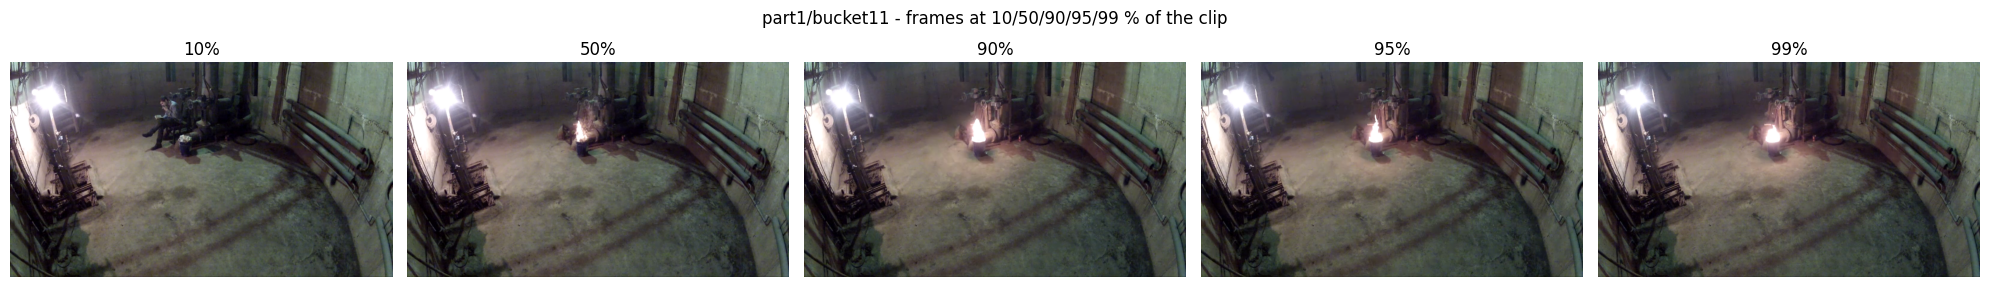

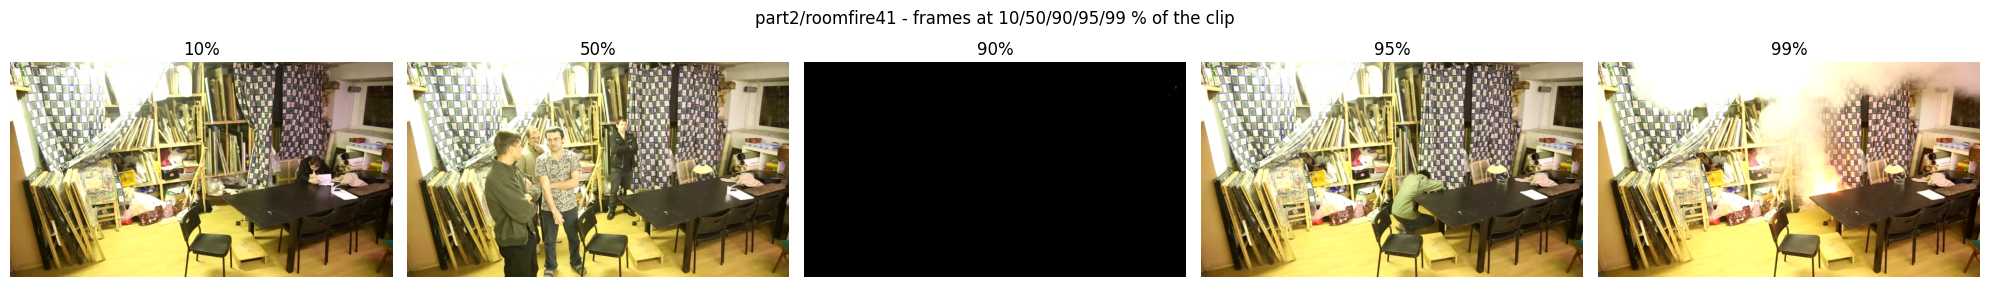

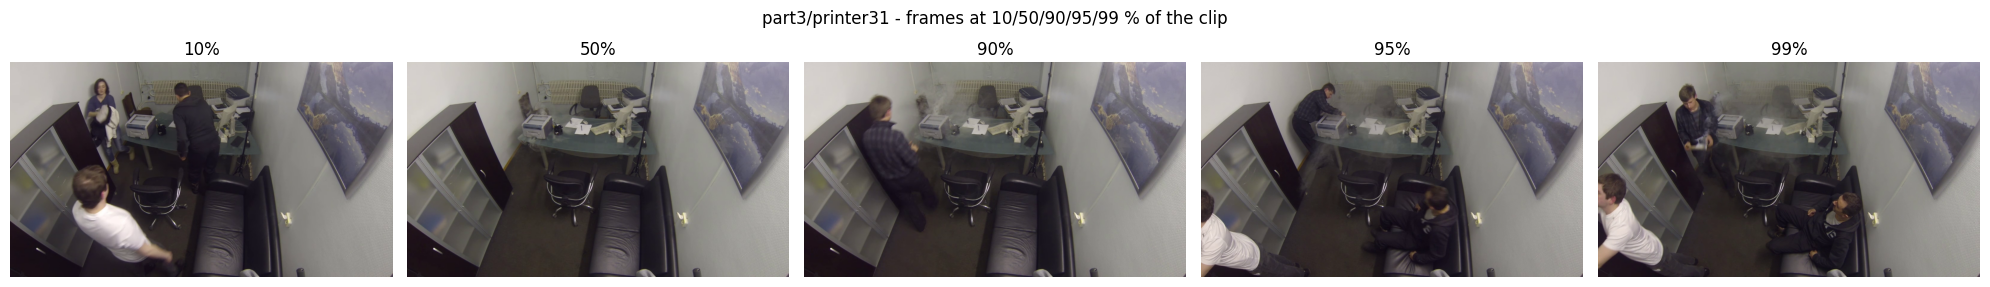

In [7]:
# Show 5 frames from each video, intentionally including very late timestamps
# (90% / 99%) so the fire/smoke event is visible.
for label, path in VIDEOS:
    info = video_info(path)
    fracs    = [0.10, 0.50, 0.90, 0.95, 0.99]
    indices  = [int(info['frames'] * f) for f in fracs]
    frames   = grab_frames(path, indices)
    titles   = [f'{int(f*100)}%' for f in fracs]
    fig, axes = plt.subplots(1, len(frames), figsize=(4 * len(frames), 3))
    for ax, fr, t in zip(axes, frames, titles):
        ax.imshow(fr); ax.set_title(t); ax.axis('off')
    fig.suptitle(f'{label} - frames at 10/50/90/95/99 % of the clip', fontsize=12)
    plt.tight_layout(); plt.show()


---
# Image Processing Pipeline

Pipeline:

1. **Resize** to a working width (cheaper to process, results are identical at the visualization scale we need).
2. **Grayscale conversion** — collapses 3 channels into 1.
3. **Gaussian blur** — suppresses sensor noise so background subtraction does not fire on speckle.
4. **Background subtraction (MOG2)** — separates moving foreground from a learned background.
5. **Frame differencing** — computed against a frame ~8 frames earlier; complements MOG2 by catching slow motion
   that MOG2 absorbs into its background model.
6. **Thresholding + morphology** — clean binary mask of moving pixels.
7. **Contour detection** — extracts connected regions for downstream area / aspect filtering.


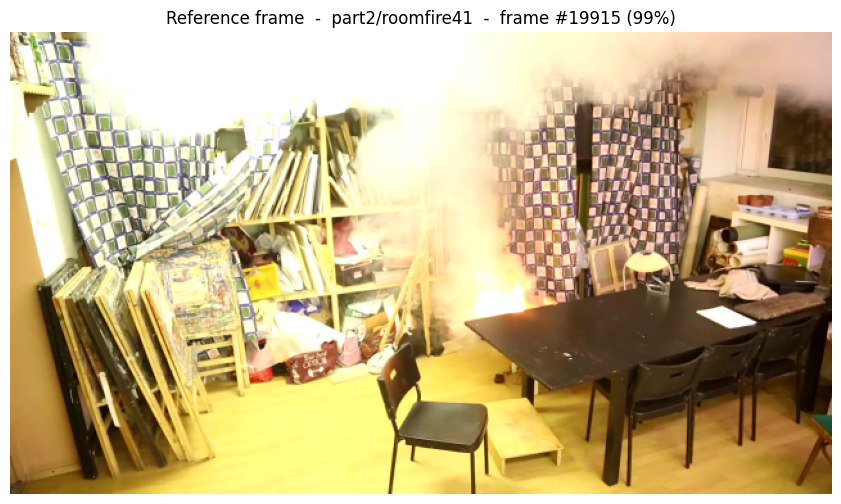

In [8]:
def resize_keep_aspect(frame, target_w):
    h0, w0 = frame.shape[:2]
    if w0 == target_w:
        return frame
    new_h = int(round(h0 * target_w / w0))
    return cv2.resize(frame, (target_w, new_h), interpolation=cv2.INTER_AREA)


ref_label, ref_path = VIDEOS[1]                          # part2 / roomfire41
ref_info = video_info(ref_path)
ref_idx  = int(ref_info['frames'] * 0.99)                # very last frames
ref_rgb_full = grab_frames(ref_path, [ref_idx])[0]
ref_bgr      = resize_keep_aspect(cv2.cvtColor(ref_rgb_full, cv2.COLOR_RGB2BGR),
                                  PARAMS['process_width'])
ref_rgb      = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(ref_rgb); plt.axis('off')
plt.title(f'Reference frame  -  {ref_label}  -  frame #{ref_idx} '
          f"({ref_idx / ref_info['frames']:.0%})")
plt.show()


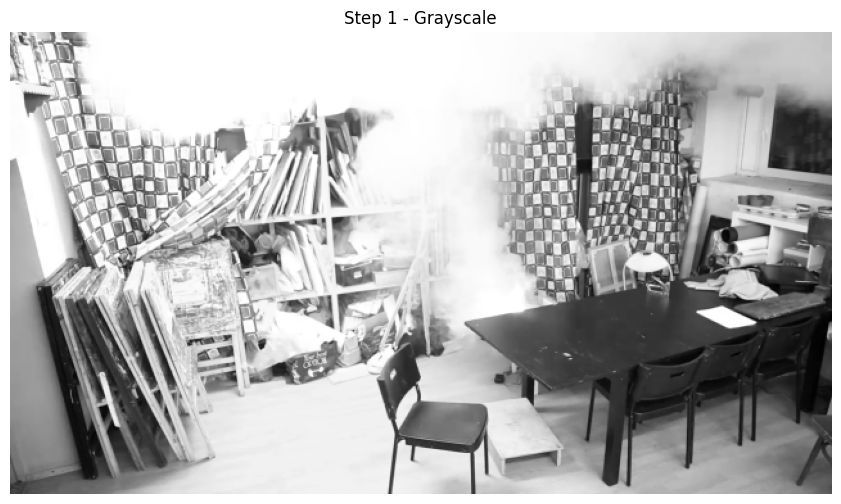

In [9]:
gray = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray'); plt.axis('off')
plt.title('Step 1 - Grayscale')
plt.show()


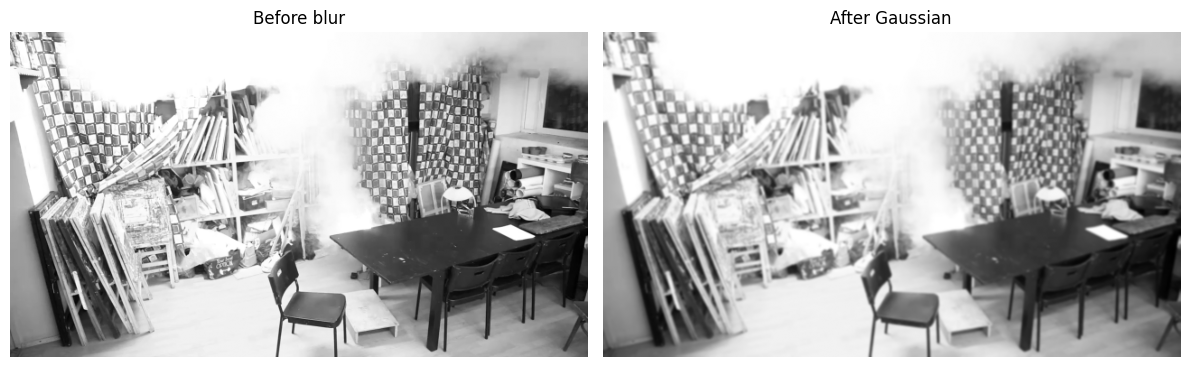

In [10]:
blurred = cv2.GaussianBlur(gray, PARAMS['blur_ksize'], 0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(gray,    cmap='gray'); ax[0].set_title('Before blur');     ax[0].axis('off')
ax[1].imshow(blurred, cmap='gray'); ax[1].set_title('After Gaussian');  ax[1].axis('off')
plt.tight_layout(); plt.show()


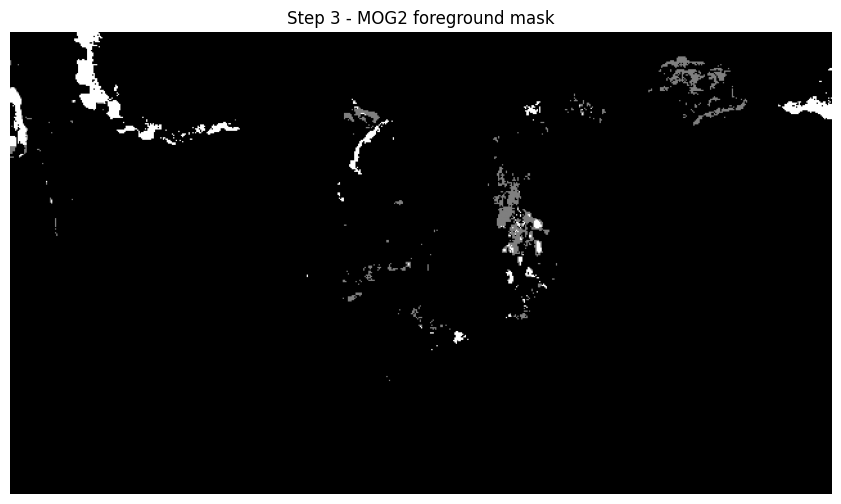

In [ ]:
def warmup(path: Path, until_idx: int, process_width: int = None,
           buffer_len: int = 12):
    
    pw = process_width or PARAMS['process_width']
    bg = cv2.createBackgroundSubtractorMOG2(
        history=PARAMS['mog2_history'],
        varThreshold=PARAMS['mog2_var_threshold'],
        detectShadows=PARAMS['mog2_detect_shadows'],
    )
    cap = cv2.VideoCapture(str(path))
    grays = deque(maxlen=buffer_len)
    n = 0
    while n <= until_idx:
        ok, frame = cap.read()
        if not ok: break
        frame   = resize_keep_aspect(frame, pw)
        blurred = cv2.GaussianBlur(frame, PARAMS['blur_ksize'], 0)
        bg.apply(blurred)
        grays.append(cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY))
        n += 1
    cap.release()
    return bg, grays


bg_subtractor, gray_history = warmup(ref_path, ref_idx)

fg_mask = bg_subtractor.apply(cv2.GaussianBlur(ref_bgr, PARAMS['blur_ksize'], 0))
plt.imshow(fg_mask, cmap='gray'); plt.axis('off')
plt.title('Step 3 - MOG2 foreground mask')
plt.show()


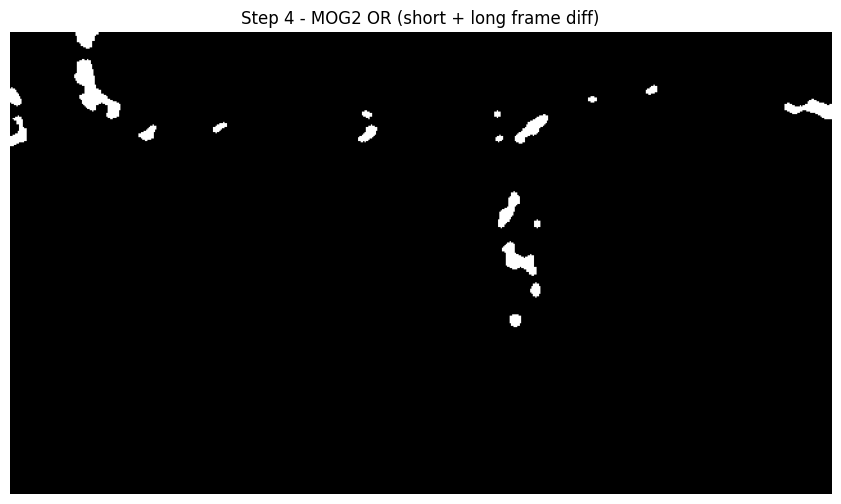

In [12]:
def compute_motion_mask(frame_bgr, bg_subtractor, gray_history):
    """Combine MOG2 + short-window + long-window frame differences."""
    blurred = cv2.GaussianBlur(frame_bgr, PARAMS['blur_ksize'], 0)
    fg      = bg_subtractor.apply(blurred)
    _, mog  = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)

    gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
    motion = mog.copy()

    # short = 1 frame back, long = diff_long_dt frames back
    candidates = []
    if len(gray_history) >= 2:
        candidates.append(gray_history[-2])
    if len(gray_history) >= PARAMS['diff_long_dt']:
        candidates.append(gray_history[-PARAMS['diff_long_dt']])

    for prev in candidates:
        diff = cv2.absdiff(gray, prev)
        _, fdiff = cv2.threshold(diff, PARAMS['diff_threshold'], 255, cv2.THRESH_BINARY)
        motion = cv2.bitwise_or(motion, fdiff)

    motion = cv2.morphologyEx(motion, cv2.MORPH_OPEN,  PARAMS['morph_kernel'])
    motion = cv2.morphologyEx(motion, cv2.MORPH_CLOSE, PARAMS['morph_kernel'], iterations=2)
    return motion, gray


motion_mask, _ = compute_motion_mask(ref_bgr, bg_subtractor, gray_history)
plt.imshow(motion_mask, cmap='gray'); plt.axis('off')
plt.title('Step 4 - MOG2 OR (short + long frame diff)')
plt.show()


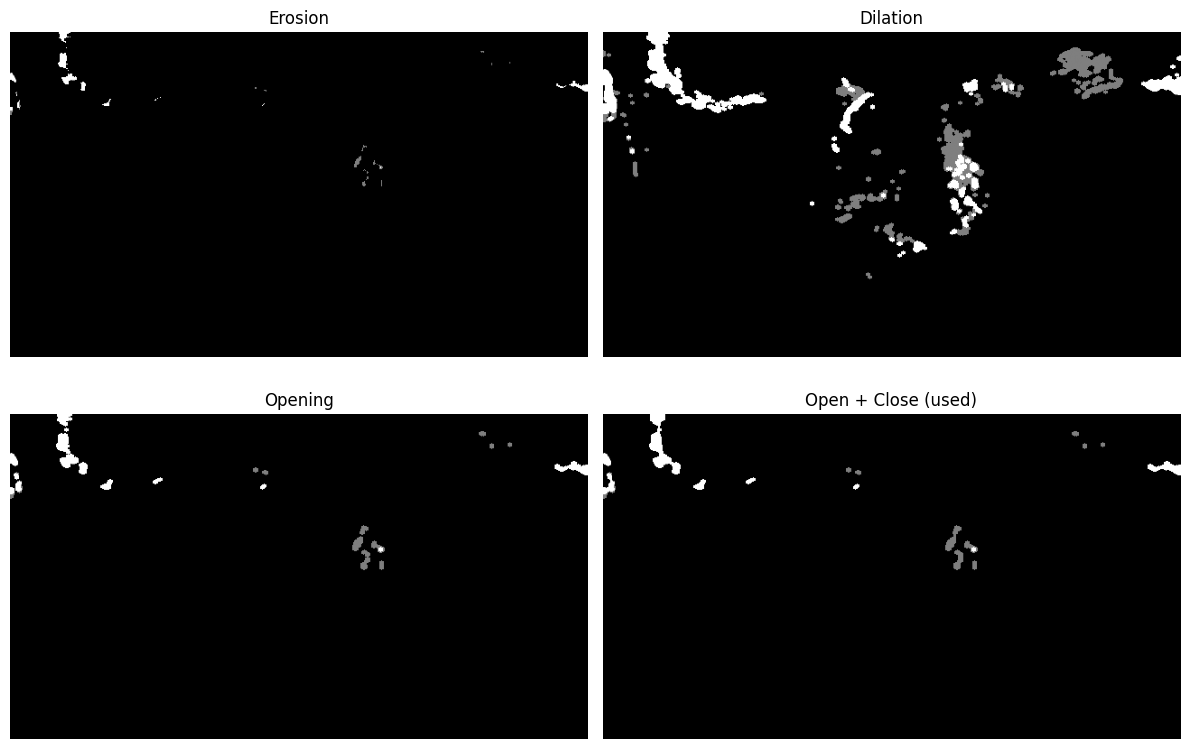

In [13]:
kernel  = PARAMS['morph_kernel']

eroded   = cv2.erode (fg_mask, kernel, iterations=1)
dilated  = cv2.dilate(fg_mask, kernel, iterations=1)
opened   = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  kernel)
closed   = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].imshow(eroded,  cmap='gray'); ax[0,0].set_title('Erosion');             ax[0,0].axis('off')
ax[0,1].imshow(dilated, cmap='gray'); ax[0,1].set_title('Dilation');            ax[0,1].axis('off')
ax[1,0].imshow(opened,  cmap='gray'); ax[1,0].set_title('Opening');             ax[1,0].axis('off')
ax[1,1].imshow(closed,  cmap='gray'); ax[1,1].set_title('Open + Close (used)'); ax[1,1].axis('off')
plt.tight_layout(); plt.show()


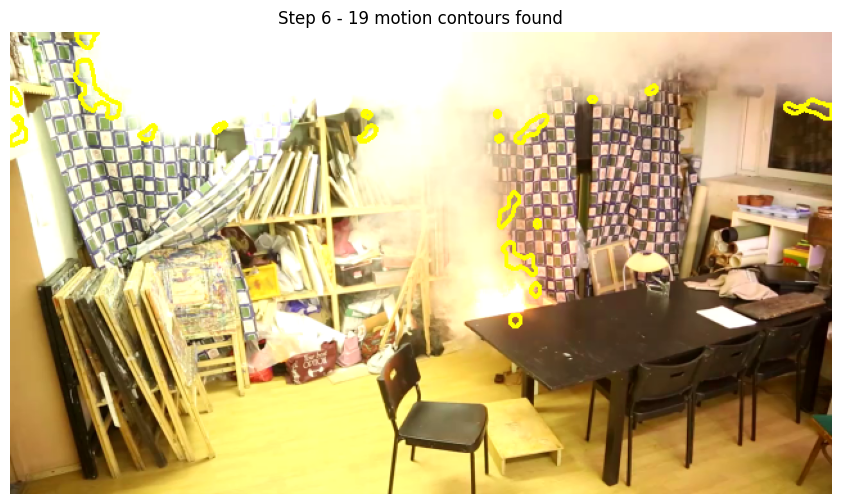

In [14]:
contours, _ = cv2.findContours(motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

vis = ref_bgr.copy()
cv2.drawContours(vis, contours, -1, (0, 255, 255), 2)        # yellow outlines
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.title(f'Step 6 - {len(contours)} motion contours found')
plt.show()


In [ ]:
def detect_humans(motion_mask):
    if motion_mask is None or not motion_mask.any():
        return [], np.zeros((1, 1), np.uint8) if motion_mask is None else motion_mask

    contours, _ = cv2.findContours(motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < PARAMS['min_area_human']:
            continue
        x, y, w, h = cv2.boundingRect(c)
        aspect = h / max(w, 1)
        if not (1.0 <= aspect <= 4.5):
            continue
        # Solidity: humans give roughly solid contours; very fragmented motion
        # (swaying curtains, drifting smoke) does not.
        hull_area = cv2.contourArea(cv2.convexHull(c)) or 1
        if area / hull_area < 0.45:
            continue
        boxes.append((x, y, w, h))
    return boxes, motion_mask


In [16]:
def draw_boxes(frame_bgr, boxes, color, label):
    """Draw rectangles + label on a copy of the frame and return it."""
    out = frame_bgr.copy()
    for (x, y, w, h) in boxes:
        cv2.rectangle(out, (x, y), (x + w, y + h), color, 2)
        cv2.putText(out, label, (x, max(15, y - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return out


In [18]:
def detect_fire(frame_bgr, motion_mask=None):
    """Multi-cue fire detector. See the markdown above for the rules."""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    b, g, r = cv2.split(frame_bgr)
    R, G, B = r.astype(int), g.astype(int), b.astype(int)

    hue_ok     = (h <= 32) | (h >= 165)
    flame_edge = hue_ok & (v > 170) & (s > 110) & (R > G) & (R - B > 55) & (R > 160)
    flame_core = hue_ok & (v > 235) & (s > 30)  & (R >= G - 5)
    white_hot  = (s < 30)  & (v > 220) & (R > 180)        # bucket-style flames

    fire = (flame_edge | flame_core | white_hot).astype(np.uint8) * 255
    fire = cv2.morphologyEx(fire, cv2.MORPH_OPEN,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    fire = cv2.morphologyEx(fire, cv2.MORPH_CLOSE, PARAMS['morph_kernel'], iterations=2)

    # Motion correlation — kills warm-lit static wood paneling.
    if motion_mask is not None and motion_mask.any():
        motion_dilated = cv2.dilate(motion_mask, np.ones((15, 15), np.uint8))
        fire = cv2.bitwise_and(fire, motion_dilated)

    contours, _ = cv2.findContours(fire, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask, boxes = np.zeros_like(fire), []
    for c in contours:
        if cv2.contourArea(c) < PARAMS['min_area_fire']:
            continue
        x, y, w, h_box = cv2.boundingRect(c)
        roi_s, roi_v = s[y:y+h_box, x:x+w], v[y:y+h_box, x:x+w]
        if roi_s.size == 0:
            continue
        peak_s, peak_v = int(roi_s.max()), int(roi_v.max())
        # Accept if (saturated orange flame) OR (very-bright white-hot core)
        if not ((peak_s >= 170 and peak_v >= 200) or peak_v >= 245):
            continue
        boxes.append((x, y, w, h_box))
        cv2.drawContours(final_mask, [c], -1, 255, -1)
    return boxes, final_mask


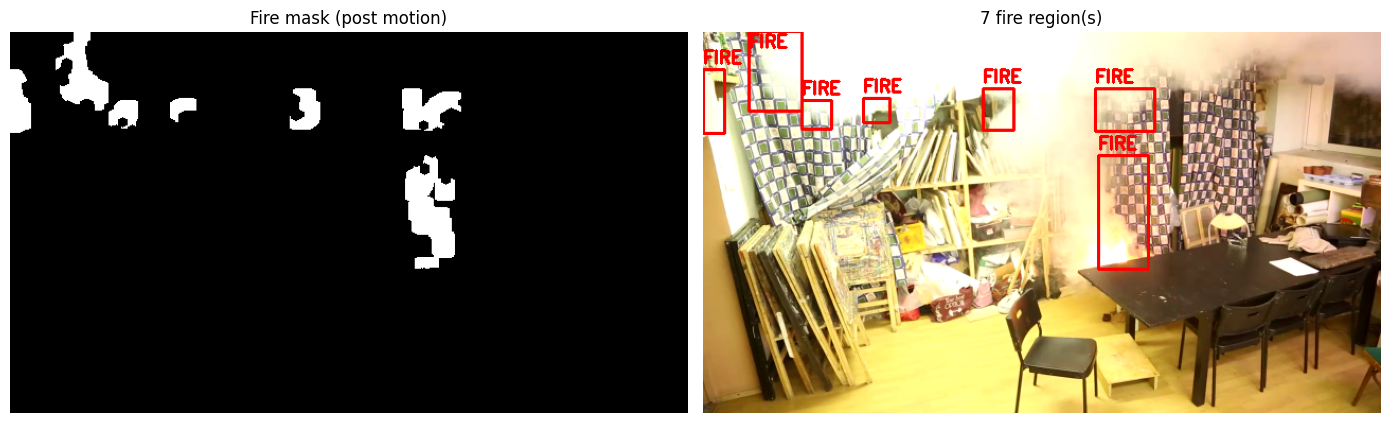

In [19]:
# Demo on the reference frame
fire_boxes, fire_mask = detect_fire(ref_bgr, motion_mask)
fire_vis = draw_boxes(ref_bgr, fire_boxes, PARAMS['color_fire'], 'FIRE')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(fire_mask, cmap='gray');                       ax[0].set_title('Fire mask (post motion)'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(fire_vis, cv2.COLOR_BGR2RGB));    ax[1].set_title(f'{len(fire_boxes)} fire region(s)'); ax[1].axis('off')
plt.tight_layout(); plt.show()


In [20]:
def detect_smoke(frame_bgr, motion_mask):
    """Multi-cue smoke detector. Motion overlap is REQUIRED."""
    hsv  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    H, _ = frame_bgr.shape[:2]

    color = cv2.inRange(hsv, (0, 0, 110), (179, 60, 245))
    color = cv2.morphologyEx(color, cv2.MORPH_OPEN,  PARAMS['morph_kernel'])
    color = cv2.morphologyEx(color, cv2.MORPH_CLOSE, PARAMS['morph_kernel'], iterations=3)

    if motion_mask is None or not motion_mask.any():
        return [], np.zeros_like(color)

    motion_dilated = cv2.dilate(motion_mask, np.ones((35, 35), np.uint8))
    candidate = cv2.bitwise_and(color, motion_dilated)
    candidate = cv2.morphologyEx(candidate, cv2.MORPH_CLOSE,
                                 cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)),
                                 iterations=2)

    contours, _ = cv2.findContours(candidate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask, boxes = np.zeros_like(color), []
    for c in contours:
        area = cv2.contourArea(c)
        if area < PARAMS['min_area_smoke']:
            continue
        x, y, w, h = cv2.boundingRect(c)
        if y > 0.75 * H:                               # smoke rises
            continue
        aspect = h / max(w, 1)
        if aspect < 0.10 or aspect > 8.0:
            continue
        roi   = gray[y:y+h, x:x+w]
        edges = cv2.Canny(roi, 60, 160)
        edge_ratio = edges.sum() / (255.0 * roi.size + 1e-6)
        if edge_ratio > 0.18:                          # too textured -> wall/object
            continue
        if roi.std() > 80:                             # not uniform enough
            continue
        cv2.drawContours(final_mask, [c], -1, 255, -1)
        boxes.append((x, y, w, h))
    return boxes, final_mask


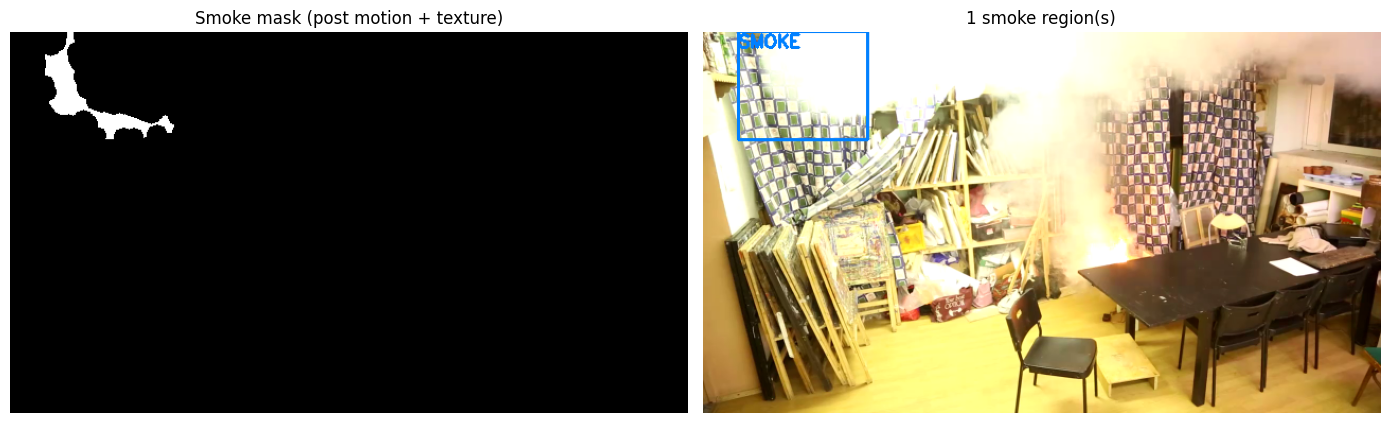

In [21]:
# Demo on the reference frame
smoke_boxes, smoke_mask = detect_smoke(ref_bgr, motion_mask)
smoke_vis = draw_boxes(ref_bgr, smoke_boxes, PARAMS['color_smoke'], 'SMOKE')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(smoke_mask, cmap='gray');                      ax[0].set_title('Smoke mask (post motion + texture)'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(smoke_vis, cv2.COLOR_BGR2RGB));   ax[1].set_title(f'{len(smoke_boxes)} smoke region(s)'); ax[1].axis('off')
plt.tight_layout(); plt.show()


---
# Combined Detection Pipeline



In [22]:
def detect_all(frame_bgr, bg_subtractor, gray_history):
    """Run all three detectors on a single BGR frame.

    Returns the annotated frame and an info dict (counts + masks).
    Also pushes the new gray frame into gray_history for the next call.
    """
    motion, gray = compute_motion_mask(frame_bgr, bg_subtractor, gray_history)
    gray_history.append(gray)

    human_boxes, _           = detect_humans(motion)
    fire_boxes,  fire_mask   = detect_fire(frame_bgr, motion)
    smoke_boxes, smoke_mask  = detect_smoke(frame_bgr, motion)

    annotated = frame_bgr.copy()
    annotated = draw_boxes(annotated, smoke_boxes, PARAMS['color_smoke'], 'SMOKE')
    annotated = draw_boxes(annotated, fire_boxes,  PARAMS['color_fire'],  'FIRE')
    annotated = draw_boxes(annotated, human_boxes, PARAMS['color_human'], 'HUMAN')

    return annotated, {
        'humans': len(human_boxes),
        'fires':  len(fire_boxes),
        'smokes': len(smoke_boxes),
        'motion_mask': motion,
        'fire_mask':   fire_mask,
        'smoke_mask':  smoke_mask,
    }


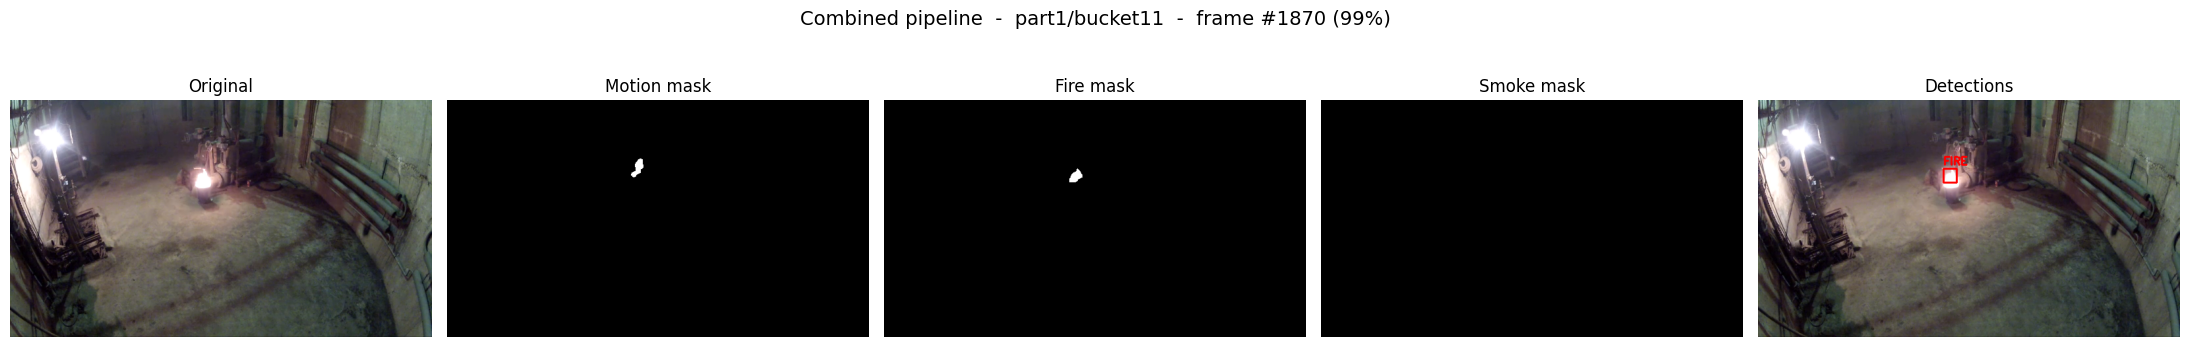

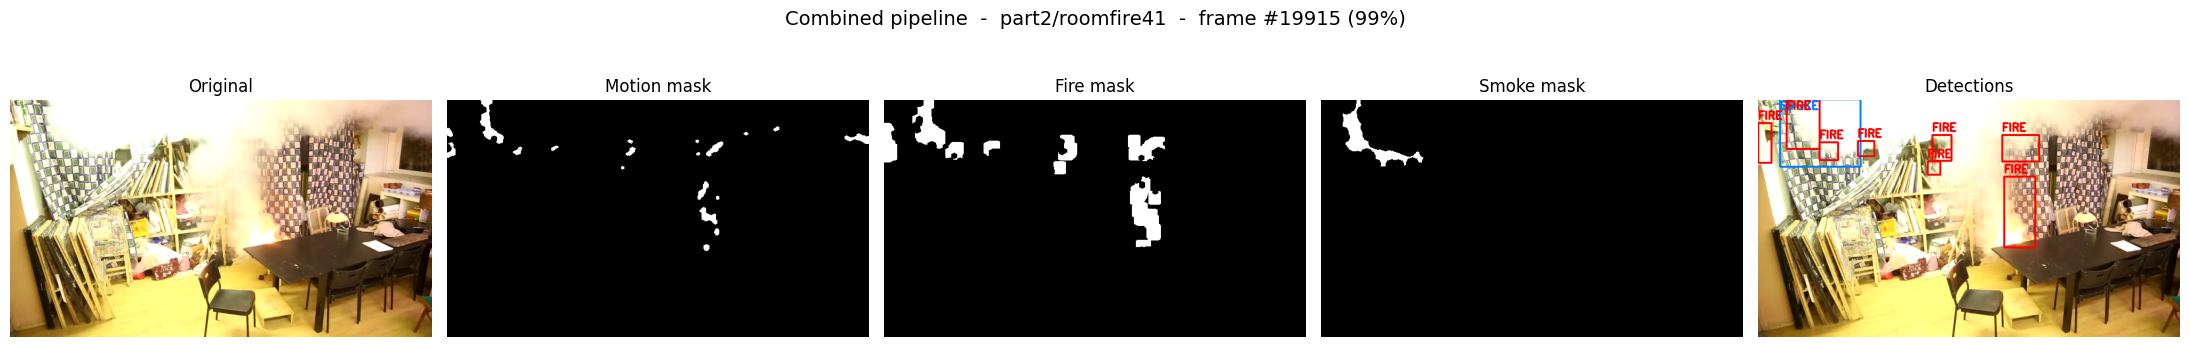

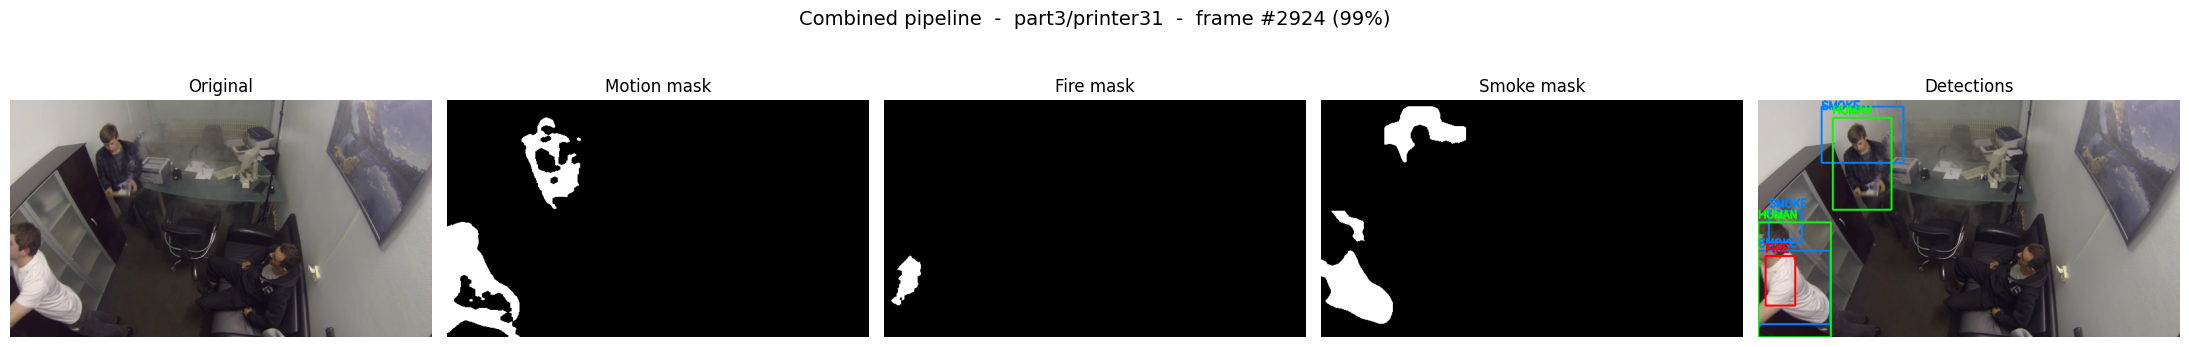

In [23]:
def show_pipeline_panels(label, path, frac=0.99):
    info  = video_info(path)
    idx   = int(info['frames'] * frac)
    raw   = grab_frames(path, [idx])[0]                    # RGB
    bgr   = resize_keep_aspect(cv2.cvtColor(raw, cv2.COLOR_RGB2BGR),
                               PARAMS['process_width'])
    rgb   = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    bg, history = warmup(path, idx)
    annotated, masks = detect_all(bgr, bg, history)

    fig, ax = plt.subplots(1, 5, figsize=(22, 4))
    ax[0].imshow(rgb);                                                  ax[0].set_title('Original')
    ax[1].imshow(masks['motion_mask'], cmap='gray');                    ax[1].set_title('Motion mask')
    ax[2].imshow(masks['fire_mask'],   cmap='gray');                    ax[2].set_title('Fire mask')
    ax[3].imshow(masks['smoke_mask'],  cmap='gray');                    ax[3].set_title('Smoke mask')
    ax[4].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB));           ax[4].set_title('Detections')
    for a in ax: a.axis('off')
    fig.suptitle(f'Combined pipeline  -  {label}  -  frame #{idx} ({frac:.0%})', fontsize=14)
    plt.tight_layout(); plt.show()


for label, path in VIDEOS:
    show_pipeline_panels(label, path, frac=0.99)


---
# Process all videos and save the annotated output



In [ ]:
def process_video(label, in_path, out_path,
                  max_frames=None, process_width=None, tail=True):
    cap = cv2.VideoCapture(str(in_path))
    if not cap.isOpened():
        raise IOError(f'Cannot open {in_path}')

    max_frames    = max_frames    or PARAMS['max_frames']
    process_width = process_width or PARAMS['process_width']

    fps    = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    n_proc = min(total, max_frames) if max_frames else total
    start  = max(0, total - n_proc) if tail else 0

    # Read one frame to know the output size after resizing
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    ok, first = cap.read()
    if not ok:
        cap.release()
        raise IOError(f'Empty video: {in_path}')
    sample = resize_keep_aspect(first, process_width)
    out_h, out_w = sample.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(out_path), fourcc, fps, (out_w, out_h))

    bg = cv2.createBackgroundSubtractorMOG2(
        history=PARAMS['mog2_history'],
        varThreshold=PARAMS['mog2_var_threshold'],
        detectShadows=PARAMS['mog2_detect_shadows'],
    )
    history = deque(maxlen=12)

    # Warm up MOG2 + history with the first ~30 frames of the segment we will
    # process. Without a warmup, MOG2 flags everything as foreground initially.
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    for _ in range(min(30, n_proc)):
        ok, f = cap.read()
        if not ok: break
        f = resize_keep_aspect(f, process_width)
        blurred = cv2.GaussianBlur(f, PARAMS['blur_ksize'], 0)
        bg.apply(blurred)
        history.append(cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY))

    # Now process from `start` to `start + n_proc`.
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    stats = {'humans': [], 'fires': [], 'smokes': []}
    pbar  = tqdm(total=n_proc, desc=label, leave=False)
    n = 0
    while n < n_proc:
        ok, frame = cap.read()
        if not ok: break
        frame = resize_keep_aspect(frame, process_width)
        annotated, info = detect_all(frame, bg, history)

        # HUD with the per-frame counts
        hud = f"H:{info['humans']}  F:{info['fires']}  S:{info['smokes']}"
        cv2.putText(annotated, hud, (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

        writer.write(annotated)
        for k in stats:
            stats[k].append(info[k])
        n += 1
        pbar.update(1)
    pbar.close()

    cap.release()
    writer.release()
    del writer, cap; gc.collect()    # release Windows file handle promptly
    return stats


In [25]:
# Run the whole pipeline on the three videos
results = {}
for label, path in tqdm(VIDEOS, desc='videos'):
    out_path = OUTPUT_DIR / f"{Path(label).name}_annotated.mp4"
    results[label] = {
        'output': out_path,
        'stats':  process_video(label, path, out_path, tail=True),
    }
    gc.collect(); time.sleep(0.3)
    print(f"  -> {out_path}  ({out_path.stat().st_size / 1e6:.1f} MB)")


videos:   0%|          | 0/3 [00:00<?, ?it/s]

part1/bucket11:   0%|          | 0/900 [00:00<?, ?it/s]

  -> outputs\bucket11_annotated.mp4  (7.1 MB)


part2/roomfire41:   0%|          | 0/900 [00:00<?, ?it/s]

  -> outputs\roomfire41_annotated.mp4  (14.6 MB)


part3/printer31:   0%|          | 0/900 [00:00<?, ?it/s]

  -> outputs\printer31_annotated.mp4  (3.6 MB)


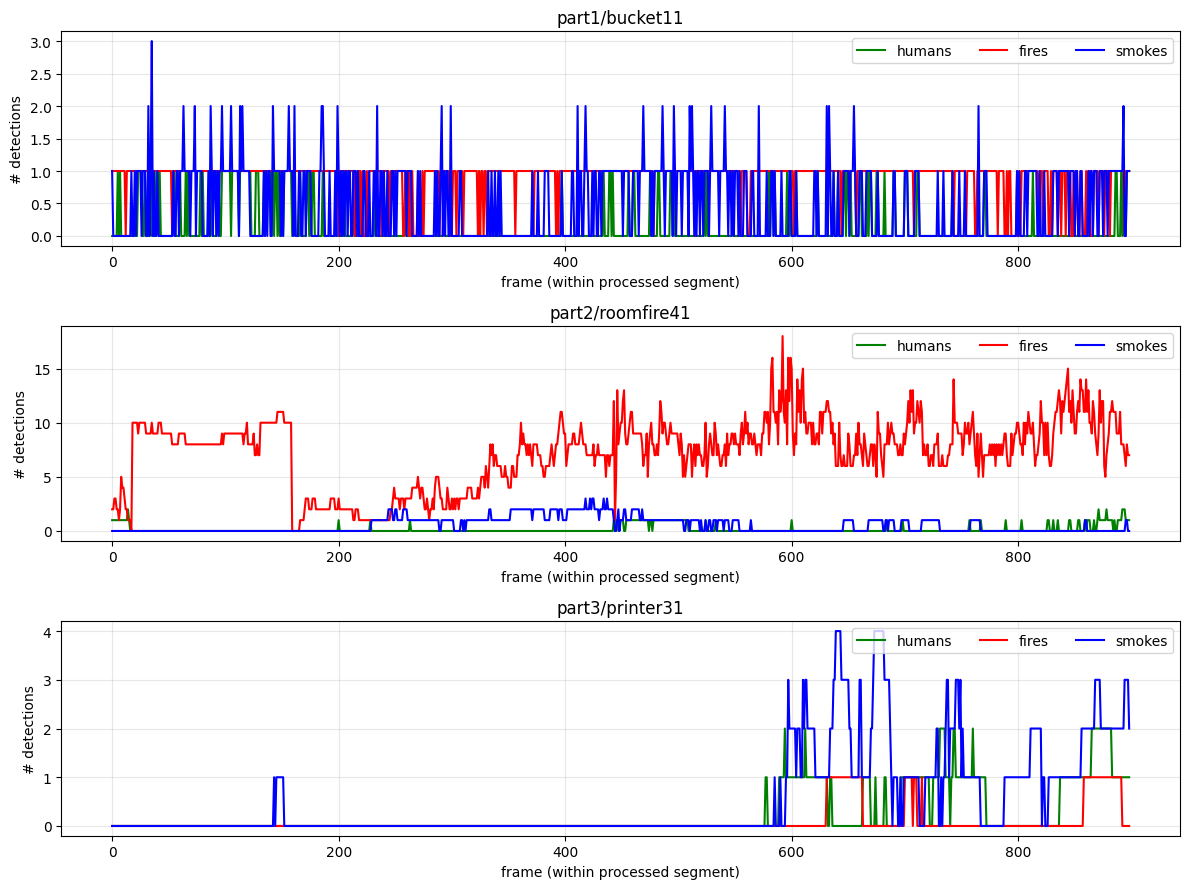

In [26]:
fig, axes = plt.subplots(len(results), 1, figsize=(12, 3 * len(results)), sharex=False)
axes = np.atleast_1d(axes)
for ax, (label, r) in zip(axes, results.items()):
    s = r['stats']
    ax.plot(s['humans'], color='green',  label='humans')
    ax.plot(s['fires'],  color='red',    label='fires')
    ax.plot(s['smokes'], color='blue',   label='smokes')
    ax.set_title(label)
    ax.set_xlabel('frame (within processed segment)')
    ax.set_ylabel('# detections')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', ncol=3)
plt.tight_layout(); plt.show()


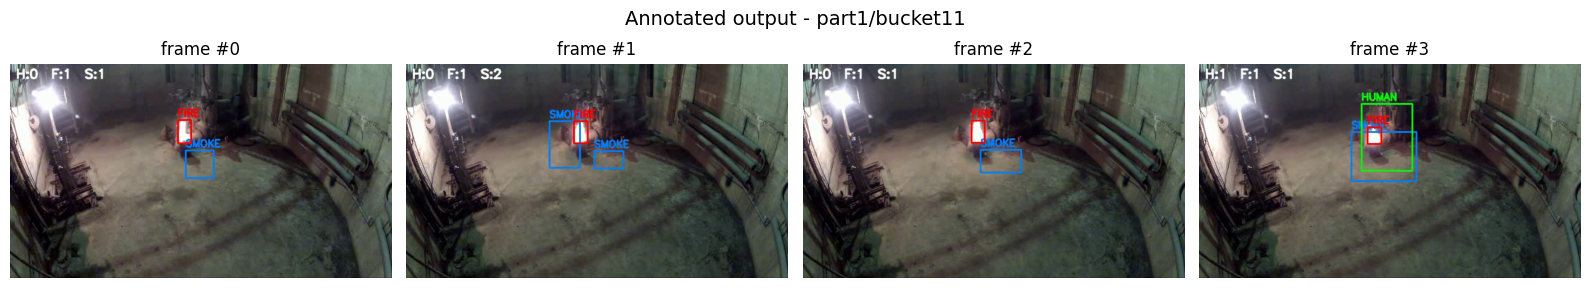

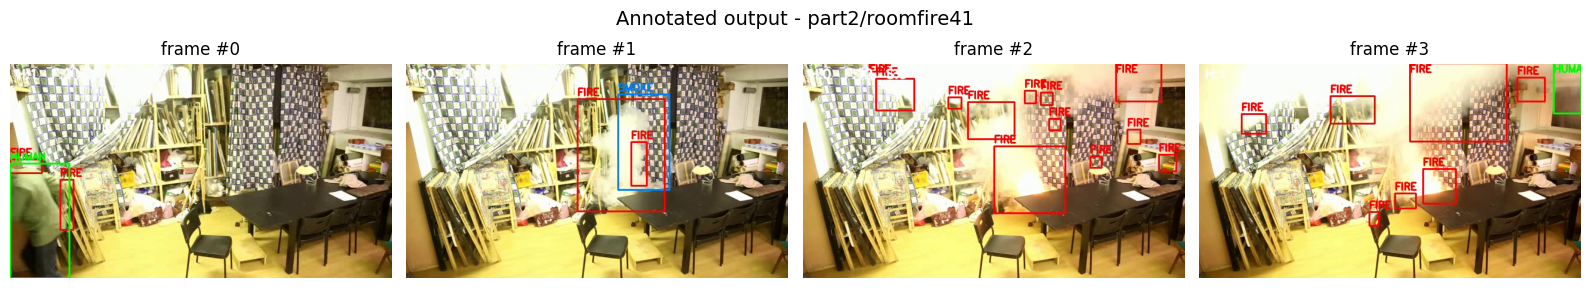

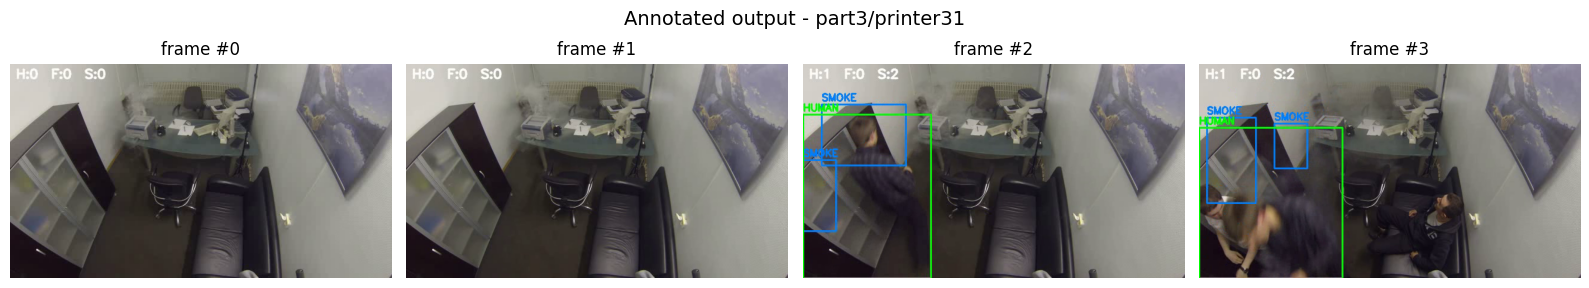

In [27]:
for label, r in results.items():
    info    = video_info(r['output'])
    indices = np.linspace(0, max(0, info['frames'] - 1), 4, dtype=int)
    frames  = grab_frames(r['output'], indices)
    show_frames_grid(frames, f'Annotated output - {label}')
